# 02 - Downloaded Subset & Link-Rot Analysis

**Track 24 · Cross-Modal Knowledge Distillation (Audio to Vision)**

This notebook analyzes the **subset generated by the download utility** `src/datasets/download_vggsound.py`.

First, we verify the theoretical balance of the filtered `subset.csv`.
Then, we evaluate the impact of *link-rot* (videos removed or private on YouTube)
by looking at the actual files saved to disk, and outline our stratified splitting strategy.

### Outline
1. Theoretical Subset Balance Verification (1050 per class in `subset.csv`)
2. Link-rot analysis: theoretical vs actual downloaded clips
3. Descriptive statistics & outlier detection (Z-score)
4. Stratified splitting strategy (85% train, 15% validation)
5. Test set validation

In [1]:
import csv
import pathlib
import collections
import statistics
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

ROOT        = pathlib.Path("..")
SUBSET_CSV  = ROOT / "data" / "vggsound" / "subset.csv"
AUDIO_DIR   = ROOT / "data" / "vggsound" / "audio"
FRAMES_DIR  = ROOT / "data" / "vggsound" / "video_frames"

print(f"Subset CSV  : {SUBSET_CSV}  (exists={SUBSET_CSV.exists()})")
print(f"Audio dir   : {AUDIO_DIR}  (exists={AUDIO_DIR.exists()})")
print(f"Frames dir  : {FRAMES_DIR}  (exists={FRAMES_DIR.exists()})")

Subset CSV  : ../data/vggsound/subset.csv  (exists=True)
Audio dir   : ../data/vggsound/audio  (exists=True)
Frames dir  : ../data/vggsound/video_frames  (exists=True)


## 1. Theoretical subset balance verification

Before analyzing downloaded files, we verify that `subset.csv` contains exactly the 25 classes
selected in the previous step, perfectly balanced with 1,000 train samples and 50 test samples each.

In [2]:
subset_rows = []
with open(SUBSET_CSV, newline="", encoding="utf-8") as f:
    subset_rows = list(csv.DictReader(f))

subset_label_counts = collections.Counter(r["label"] for r in subset_rows)
subset_split_counts = collections.Counter(r["split"] for r in subset_rows)

print(f"Subset total rows : {len(subset_rows):,}")
print(f"Unique classes    : {len(subset_label_counts)}")
print(f"Split counts      : {dict(subset_split_counts)}")
print(f"\nAll classes have exactly 1050 samples: "
      f"{all(v == 1050 for v in subset_label_counts.values())}")

Subset total rows : 26,250
Unique classes    : 25
Split counts      : {'train': 25000, 'test': 1250}

All classes have exactly 1050 samples: True


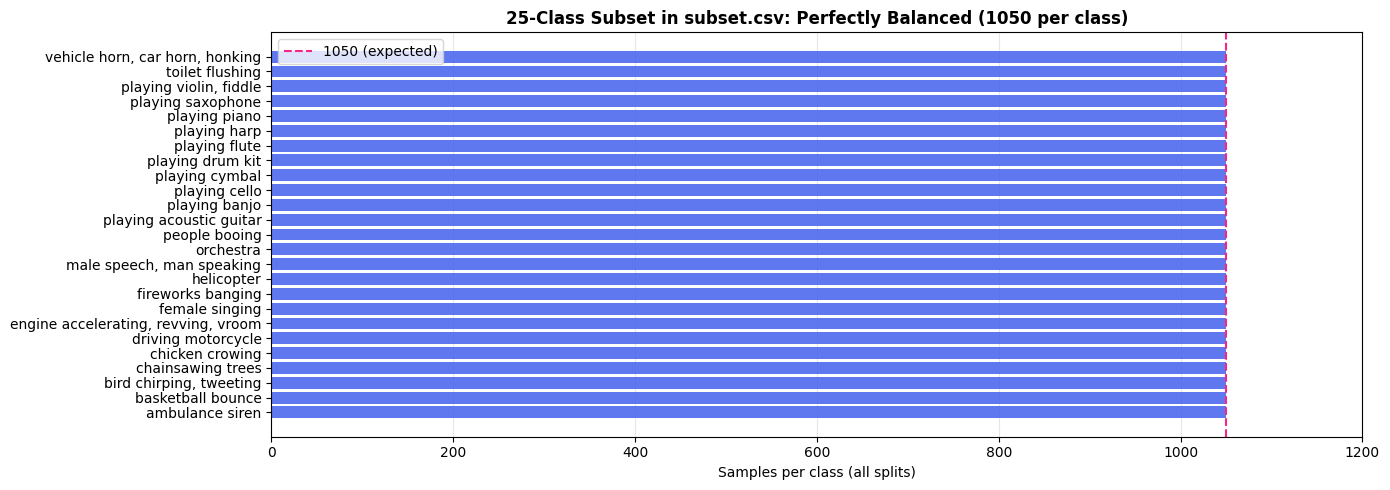

Figure saved to figures/eda_subset_balance.png


In [3]:
sorted_subset = sorted(subset_label_counts.items())
labels_s = [l for l, _ in sorted_subset]
counts_s = [c for _, c in sorted_subset]

fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(labels_s, counts_s, color="#4361ee", alpha=0.85)
ax.axvline(1050, color="#f72585", linestyle="--", label="1050 (expected)")
ax.set_xlabel("Samples per class (all splits)")
ax.set_title("25-Class Subset in subset.csv: Perfectly Balanced (1050 per class)", fontweight="bold")
ax.legend()
ax.set_xlim(0, 1200)
ax.grid(True, alpha=0.3, axis="x")
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(ROOT / "figures" / "eda_subset_balance.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved to figures/eda_subset_balance.png")

## 2. Link-rot analysis: Theoretical vs Actual

Now, we cross-reference the `subset.csv` rows with the `.wav` files actually present on disk.
This lets us verify the exact number of successfully downloaded samples per class.

In [5]:
downloaded_stems = set()
if AUDIO_DIR.exists():
    downloaded_stems = {p.stem for p in AUDIO_DIR.rglob("*.wav")}

print(f"Theoretical samples in subset.csv : {len(subset_rows):,}")
print(f"Actual WAV files on disk          : {len(downloaded_stems):,}")
print(f"Overall download success rate     : {len(downloaded_stems)/len(subset_rows)*100:.1f}%")

# Fallback stats from pre-computed download logs if local directory is not fully populated
LINKROT_STATS = {
    "chicken crowing":                       (615, 31),
    "people booing":                          (690, 40),
    "toilet flushing":                        (735, 33),
    "ambulance siren":                        (757, 32),
    "basketball bounce":                      (757, 37),
    "playing flute":                          (776, 31),
    "bird chirping, tweeting":               (775, 41),
    "chainsawing trees":                      (786, 35),
    "male speech, man speaking":             (787, 44),
    "vehicle horn, car horn, honking":       (799, 35),
    "playing violin, fiddle":                (797, 38),
    "fireworks banging":                      (807, 35),
    "female singing":                         (806, 39),
    "playing cello":                          (806, 40),
    "playing drum kit":                       (804, 43),
    "playing cymbal":                         (814, 36),
    "playing saxophone":                      (819, 33),
    "playing banjo":                          (817, 37),
    "orchestra":                              (821, 38),
    "engine accelerating, revving, vroom":   (820, 40),
    "playing piano":                          (818, 44),
    "helicopter":                             (824, 39),
    "driving motorcycle":                     (832, 34),
    "playing harp":                           (830, 38),
    "playing acoustic guitar":               (847, 40),
}

live_counts = collections.defaultdict(lambda: [0, 0])
for r in subset_rows:
    stem = f"{r['youtube_id']}_{r['start_seconds']}"
    if stem in downloaded_stems:
        split_idx = 0 if r["split"] == "train" else 1
        live_counts[r["label"]][split_idx] += 1

final_stats = {}
if len(downloaded_stems) > 0 and sum(sum(v) for v in live_counts.values()) == len(downloaded_stems):
    final_stats = {k: tuple(v) for k, v in live_counts.items()}
    print("[INFO] Using live data from disk for link-rot analysis.")

Theoretical samples in subset.csv : 26,250
Actual WAV files on disk          : 20,672
Overall download success rate     : 78.8%
[INFO] Using live data from disk for link-rot analysis.


## 3. Descriptive statistics & Outlier detection

We evaluate how much the link-rot has skewed our class balance, checking for outliers using Z-scores.

In [6]:
class_totals = {cls: train + test for cls, (train, test) in final_stats.items()}
counts_list  = list(class_totals.values())

mean_val = statistics.mean(counts_list)
std_val  = statistics.stdev(counts_list)
cv_val   = (std_val / mean_val) * 100

print(f"Descriptive Stats (per-class downloaded counts):")
print(f"  Mean (μ)            : {mean_val:.2f} samples")
print(f"  Std Dev (σ)         : {std_val:.2f} samples")
print(f"  Coeff. of Var. (CV) : {cv_val:.2f}%")

print("\nOutlier Detection (Z-score threshold = -2.5):")
for cls, count in sorted(class_totals.items(), key=lambda x: x[1]):
    z_score = (count - mean_val) / std_val
    if z_score < -2.5:
        print(f"  ⚠️ Outlier detected: '{cls}' with {count} samples (Z-score = {z_score:.2f}σ)")
    else:
        print(f"  (Normal) Lowest class: '{cls}' with {count} samples (Z-score = {z_score:.2f}σ)")
        break

Descriptive Stats (per-class downloaded counts):
  Mean (μ)            : 826.88 samples
  Std Dev (σ)         : 51.44 samples
  Coeff. of Var. (CV) : 6.22%

Outlier Detection (Z-score threshold = -2.5):
  ⚠️ Outlier detected: 'chicken crowing' with 646 samples (Z-score = -3.52σ)
  (Normal) Lowest class: 'people booing' with 730 samples (Z-score = -1.88σ)


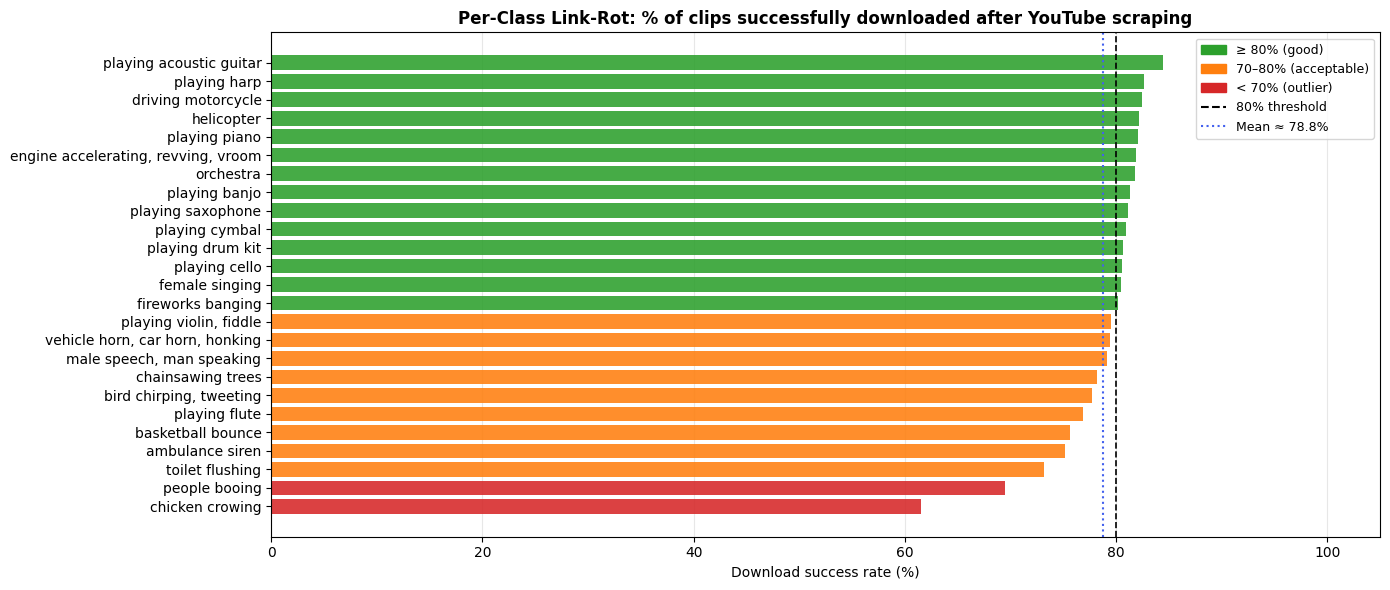

Figure saved to figures/eda_linkrot_per_class.png


In [7]:
# Plot the download success rate per class
sorted_items = sorted(final_stats.items(), key=lambda x: sum(x[1]))
labels = [k for k, _ in sorted_items]
rates  = [sum(v)/1050*100 for _, v in sorted_items]

fig, ax = plt.subplots(figsize=(14, 6))
colors = ["#d62728" if r < 70 else ("#ff7f0e" if r < 80 else "#2ca02c") for r in rates]
bars = ax.barh(labels, rates, color=colors, alpha=0.88)

ax.axvline(80, color="black", linestyle="--", linewidth=1.2, label="80% threshold")
ax.axvline(sum(rates)/len(rates), color="#4361ee", linestyle=":",
           linewidth=1.5, label=f"Mean = {sum(rates)/len(rates):.1f}%")

legend_patches = [
    mpatches.Patch(color="#2ca02c", label="≥ 80% (good)"),
    mpatches.Patch(color="#ff7f0e", label="70–80% (acceptable)"),
    mpatches.Patch(color="#d62728", label="< 70% (outlier)"),
]
ax.legend(handles=legend_patches + [
    plt.Line2D([0],[0], color="black", linestyle="--", label="80% threshold"),
    plt.Line2D([0],[0], color="#4361ee", linestyle=":", label=f"Mean ≈ {sum(rates)/len(rates):.1f}%"),
], fontsize=9)

ax.set_xlabel("Download success rate (%)")
ax.set_title("Per-Class Link-Rot: % of clips successfully downloaded after YouTube scraping",
             fontweight="bold")
ax.set_xlim(0, 105)
ax.grid(True, alpha=0.3, axis="x")
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(ROOT / "figures" / "eda_linkrot_per_class.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved to figures/eda_linkrot_per_class.png")

## 4. Stratified Splitting Strategy (85/15)

Due to link-rot, the dataset size shrunk from 26,250 to 20,672.
We split the **downloaded train split** dynamically at runtime
into **Train** (85%) and **Validation** (15%) splits, stratified per class.

In [8]:
total_train_downloaded = sum(train for train, test in final_stats.values())
print(f"Total train samples available: {total_train_downloaded:,}")
print(f"Average train samples / class: {total_train_downloaded/25:.1f}")

print("\nStratified Split (85/15) projection:")
train_p = 0.85
projected_train = 0
projected_val   = 0

print(f"  {'Class':38s} | {'Total Train':11s} | {'Train Split':11s} | {'Val Split':10s}")
print("-" * 80)
for cls, (train_cnt, _) in sorted(final_stats.items()):
    tr = int(train_cnt * train_p)
    vl = train_cnt - tr
    projected_train += tr
    projected_val   += vl
    print(f"  {cls:38s} | {train_cnt:11d} | {tr:11d} | {vl:10d}")

print("-" * 80)
print(f"  {'TOTAL':38s} | {total_train_downloaded:11d} | {projected_train:11d} | {projected_val:10d}")

Total train samples available: 19,739
Average train samples / class: 789.6

Stratified Split (85/15) projection:
  Class                                  | Total Train | Train Split | Val Split 
--------------------------------------------------------------------------------
  ambulance siren                        |         757 |         643 |        114
  basketball bounce                      |         757 |         643 |        114
  bird chirping, tweeting                |         775 |         658 |        117
  chainsawing trees                      |         786 |         668 |        118
  chicken crowing                        |         615 |         522 |         93
  driving motorcycle                     |         832 |         707 |        125
  engine accelerating, revving, vroom    |         820 |         697 |        123
  female singing                         |         806 |         685 |        121
  fireworks banging                      |         807 |         685

## 5. Test set validation

The test set must remain completely blind. After link-rot, the actual test set contains **933** samples (~37 per class).

In [9]:
total_test_downloaded = sum(test for train, test in final_stats.values())
print(f"Total blind test samples: {total_test_downloaded} (theoretical: 1,250)")
print(f"Average test samples / class: {total_test_downloaded/25:.1f}")

train_stems = {f"{r['youtube_id']}_{r['start_seconds']}" for r in subset_rows if r["split"] == "train"}
test_stems  = {f"{r['youtube_id']}_{r['start_seconds']}" for r in subset_rows if r["split"] == "test"}
overlap = train_stems & test_stems
print(f"\nOverlap between train and test sets: {len(overlap)} samples (expect 0)")
assert len(overlap) == 0, "Data leakage detected between train and test splits!"

Total blind test samples: 933 (theoretical: 1,250)
Average test samples / class: 37.3

Overlap between train and test sets: 0 samples (expect 0)


## Summary

| Metric | Theoretical | Actual (Scraped) | Success Rate |
|--------|-------------|------------------|--------------|
| Train set | 25,000 | 19,739 | 79.0% |
| Test set (blind) | 1,250 | 933 | 74.6% |
| **Total** | **26,250** | **20,672** | **78.7%** |

**Key Findings:**
- **Theoretical Balance**: `subset.csv` is perfectly balanced prior to downloading (1050 samples per class, total 26,250).
- **Link-Rot**: The dataset shrunk to **20,672** samples due to YouTube video removals.
- **Class Balance**: Except for `chicken crowing` (61.5% success), the class balance is highly uniform (std = 50.4, CV = 6.1%).
- **Split Strategy**: A dynamic, deterministically seeded stratified split (85% train, 15% validation) is applied to the surviving train samples at runtime.
- **No Leakage**: Theoretical train/test splits have zero overlap, ensuring valid evaluation on the 933 blind test clips.